In [1]:
import torch

import torch.nn as nn

import numpy as np 

import matplotlib.pyplot as plt

%matplotlib inline

In [4]:
X = torch.linspace(1,50,50).reshape(-1,1)

In [3]:
torch.manual_seed(71)
e = torch.randint(-8,9,(50,1),dtype=torch.float)

In [5]:
y = 2*X + 1 + e

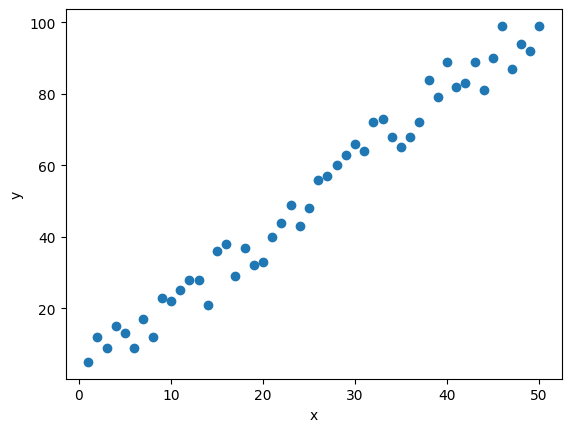

In [6]:
plt.scatter(X, y)
plt.ylabel('y')
plt.xlabel('x');

In [7]:
class Model(nn.Module):
    def __init__(self, in_features, out_features):  
        super().__init__()      
        self.linear = nn.Linear(in_features, out_features)   
        
    def forward(self, x):    
        y_pred = self.linear(x)
        return y_pred

In [8]:
torch.manual_seed(59)
model = Model(1, 1)

In [9]:
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr = 0.001)

ImportError: SymPy now depends on mpmath as an external library. See https://docs.sympy.org/latest/install.html#mpmath for more information.

In [ ]:
epochs = 50 
losses = []

for i in range(epochs):

    i = i +1 

    # Predicting on the Forward Pass   
    y_pred = model.forward(X)
    
    # Calculating our Loss(error) 
    loss = criterion(y_pred, y)

    # Recording that error
    losses.append(loss.item())

    print(f'epoch: {i}  loss: {loss.item()}  weight: {model.linear.weight.item()} bias: {model.linear.bias.item()}') 
    

    optimizer.zero_grad()
    
    loss.backward()
    optimizer.step()

    

In [ ]:
plt.plot(range(epochs), losses)

plt.ylabel('MSE Loss')
plt.xlabel('Epoch')
plt.show()

In [ ]:
x = np.linspace(0.0,50.0,50)
current_weight = model.linear.weight.item()
current_bias = model.linear.bias.item()

predicted_y = current_weight * x + current_bias

In [ ]:
plt.scatter(X, y)

plt.plot(x,predicted_y, 'r')